In [1]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms
from torch.utils.data import Dataset,DataLoader,Subset
from PIL import Image
import kagglehub

In [2]:
path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")

print(path)
print(os.listdir(path))

Using Colab cache for faster access to the 'chest-xray-pneumonia' dataset.
/kaggle/input/chest-xray-pneumonia
['chest_xray']


In [3]:
torch.manual_seed(42)
device = torch.device('cuda'if torch.cuda.is_available() else 'cpu')
print(f" Using Device {device}")

 Using Device cpu


In [4]:
TRAIN_PATH = os.path.join(path, "chest_xray", "train")
VAL_PATH = os.path.join(path, "chest_xray", "val")
TEST_PATH = os.path.join(path, "chest_xray", "test")

In [5]:
transform = transforms.Compose(
    [
        transforms.Resize( (128,128) ),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5]*3, std=[0.5]*3)
    ]
)

In [6]:
from genericpath import isfile

class MultiClassClassfication(Dataset):
  def __init__(self, root_dir,transform=None) :
    super().__init__()

    self.samples = []
    self.transform = transform

    self.classes = sorted([d for d in os.listdir(root_dir) if os.path.isdir(os.path.join(root_dir,d))])

    self.class_to_idx= {cls_name : idx  for idx,cls_name in enumerate(self.classes)}

    for class_name in self.classes:
      class_path = os.path.join(root_dir,class_name)

      for img_name in os.listdir(class_path):
        img_path = os.path.join(class_path,img_name)

        if os.path.isfile(img_path):
          label = self.class_to_idx[class_name]
          self.samples.append( (img_path,label) )


  def __len__(self):
    return len(self.samples)

  def __getitem__(self, idx) :

    img_path, label = self.samples[idx]
    image = Image.open(img_path).convert("RGB")

    if self.transform:
      image = self.transform(image)


    return image, label



In [7]:
train_dataset_full = MultiClassClassfication(TRAIN_PATH, transform)
val_dataset = MultiClassClassfication(VAL_PATH, transform)
test_dataset_full = MultiClassClassfication(TEST_PATH, transform)
num_classes = len(train_dataset_full.classes)

print("Number of classes:", num_classes)
print("Full train size:", len(train_dataset_full))
print("Full val_dataset:", len(val_dataset))
print("Full test size:", len(test_dataset_full))

Number of classes: 2
Full train size: 5216
Full val_dataset: 16
Full test size: 624


In [8]:
pin = True if device.type == 'cuda' else False
train_loader = DataLoader(train_dataset_full, batch_size=32, shuffle=True, pin_memory=pin)
val_loader = DataLoader(val_dataset,batch_size=32,shuffle=False,pin_memory=pin)
test_loader = DataLoader(test_dataset_full, batch_size=32, shuffle=False, pin_memory=pin)

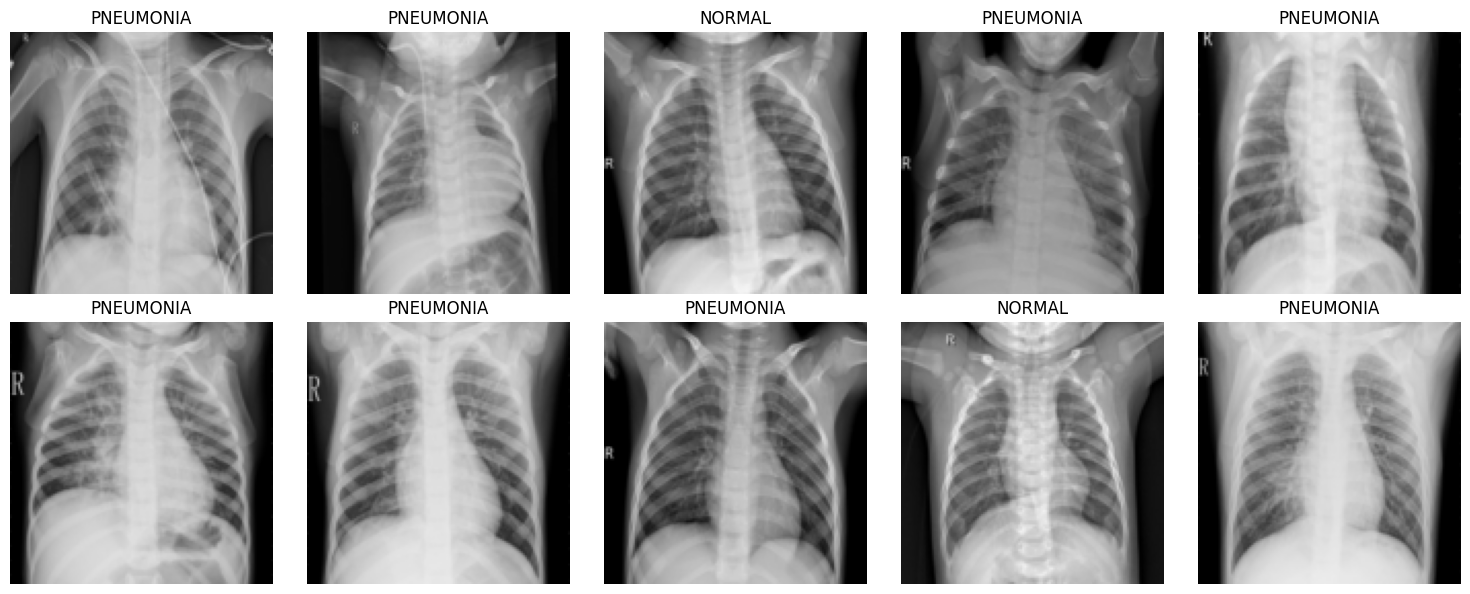

In [9]:
import matplotlib.pyplot as plt

images, labels = next(iter(train_loader))

plt.figure(figsize=(15, 6))

for i in range(10):
    plt.subplot(2, 5, i + 1)


    img = images[i].permute(1, 2, 0).cpu()
    img = img * 0.5 + 0.5
    img = img.clamp(0, 1)

    plt.imshow(img)


    class_name = train_dataset_full.classes[labels[i].item()]
    plt.title(class_name)

    plt.axis("off")

plt.tight_layout()
plt.show()

In [10]:
class MyCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding='same'),
            nn.ReLU(),
            nn.BatchNorm2d(32),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding='same'),
            nn.ReLU(),
            nn.BatchNorm2d(64),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding='same'),
            nn.ReLU(),
            nn.BatchNorm2d(128),
            nn.MaxPool2d(2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128*16*16, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x



In [11]:
model = MyCNN(num_classes=num_classes).to(device)

In [12]:
learning_rate = 0.001
epochs = 50
patience = 5

best_val_loss = float("inf")
counter = 0
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

In [13]:
train_losses = []
train_accs = []

val_losses = []
val_accs = []

In [14]:
for epoch in range(epochs):

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for batch_features, batch_labels in train_loader:
        batch_features = batch_features.to(device)
        batch_labels = batch_labels.to(device)
        outputs = model(batch_features)
        loss = criterion(outputs, batch_labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        total += batch_labels.size(0)
        correct += (predicted == batch_labels).sum().item()

    train_loss = running_loss / len(train_loader)
    train_acc = 100 * correct / total

    train_losses.append(train_loss)
    train_accs.append(train_acc)


    model.eval()

    running_val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for batch_features, batch_labels in val_loader:

            batch_features = batch_features.to(device)
            batch_labels = batch_labels.to(device)

            outputs = model(batch_features)

            loss = criterion(outputs, batch_labels)

            running_val_loss += loss.item()

            _, predicted = torch.max(outputs, 1)

            val_total += batch_labels.size(0)
            val_correct += (predicted == batch_labels).sum().item()

    val_loss = running_val_loss / len(val_loader)
    val_acc = 100 * val_correct / val_total

    val_losses.append(val_loss)
    val_accs.append(val_acc)

    print(f"Epoch [{epoch+1}/{epochs}]")
    print(f"Train Loss : {train_loss:.4f}")
    print(f"Train Accuracy : {train_acc:.2f}%")
    print(f"Validation Loss : {val_loss:.4f}")
    print(f"Validation Accuracy : {val_acc:.2f}%")


    if val_loss < best_val_loss:

        best_val_loss = val_loss
        counter = 0

        torch.save(model.state_dict(), "best_model.pth")
        print("Best Model Saved\n")

    else:

        counter += 1
        print(f"No Improvement ({counter}/{patience})\n")

        if counter >= patience:
            print("Early Stopping Triggered!")
            break



Epoch [1/50]
Train Loss : 0.3099
Train Accuracy : 89.57%
Validation Loss : 0.8475
Validation Accuracy : 56.25%
Best Model Saved

Epoch [2/50]
Train Loss : 0.1408
Train Accuracy : 94.71%
Validation Loss : 0.6557
Validation Accuracy : 75.00%
Best Model Saved

Epoch [3/50]
Train Loss : 0.1161
Train Accuracy : 96.01%
Validation Loss : 1.2172
Validation Accuracy : 68.75%
No Improvement (1/5)

Epoch [4/50]
Train Loss : 0.1049
Train Accuracy : 96.38%
Validation Loss : 0.4845
Validation Accuracy : 81.25%
Best Model Saved

Epoch [5/50]
Train Loss : 0.0891
Train Accuracy : 96.97%
Validation Loss : 0.5690
Validation Accuracy : 75.00%
No Improvement (1/5)

Epoch [6/50]
Train Loss : 0.0884
Train Accuracy : 97.24%
Validation Loss : 0.9261
Validation Accuracy : 68.75%
No Improvement (2/5)

Epoch [7/50]
Train Loss : 0.0782
Train Accuracy : 97.34%
Validation Loss : 0.1541
Validation Accuracy : 93.75%
Best Model Saved

Epoch [8/50]
Train Loss : 0.0636
Train Accuracy : 97.85%
Validation Loss : 1.0073
Val

In [15]:
def evaluate(loader):

    model.eval()

    total_loss = 0
    total = 0
    correct = 0

    y_true = []
    y_pred = []

    with torch.no_grad():

        for batch_features, batch_labels in loader:

            batch_features = batch_features.to(device)
            batch_labels = batch_labels.to(device)

            outputs = model(batch_features)

            loss = criterion(outputs, batch_labels)

            total_loss += loss.item()

            _, predicted = torch.max(outputs, 1)

            total += batch_labels.size(0)
            correct += (predicted == batch_labels).sum().item()

            y_true.extend(batch_labels.cpu().numpy())
            y_pred.extend(predicted.cpu().numpy())

    avg_loss = total_loss / len(loader)
    accuracy = correct / total

    return avg_loss, accuracy, y_true, y_pred

In [16]:
val_loss, val_acc, y_true, y_pred = evaluate(val_loader)

print(f"Validation Loss : {val_loss:.4f}")
print(f"Validation Accuracy : {val_acc*100:.2f}%")

Validation Loss : 0.1161
Validation Accuracy : 93.75%


In [17]:
test_loss, test_acc, y_true, y_pred = evaluate(test_loader)

print(f"Test Loss : {test_loss:.4f}")
print(f"Test Accuracy : {test_acc*100:.2f}%")

Test Loss : 1.5641
Test Accuracy : 79.81%


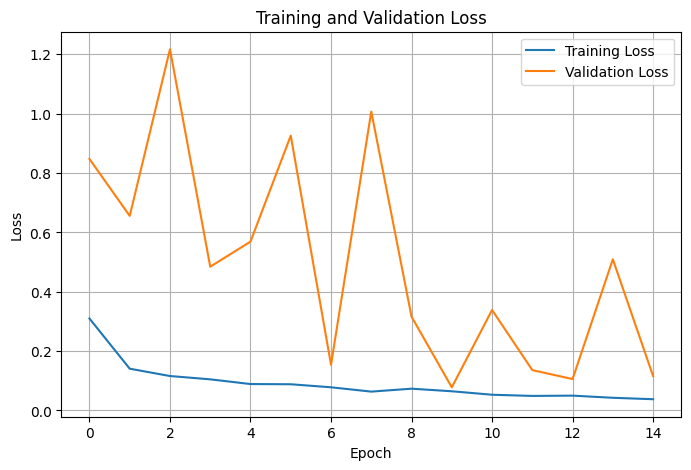

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(train_losses, label="Training Loss")
plt.plot(val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")

plt.legend()
plt.grid(True)

plt.show()

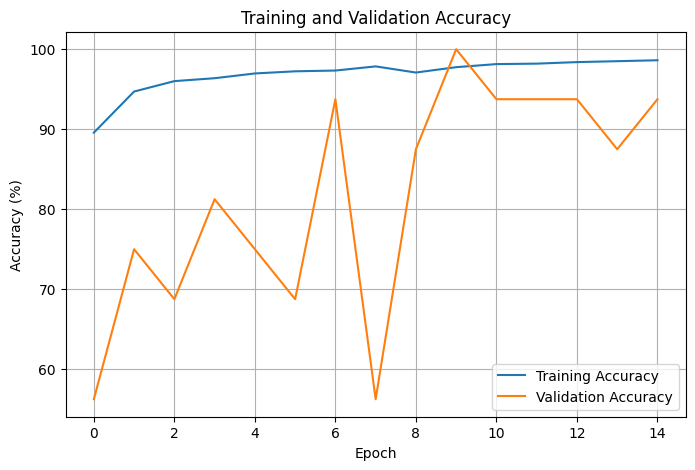

In [23]:
plt.figure(figsize=(8, 5))

plt.plot(train_accs, label="Training Accuracy")
plt.plot(val_accs, label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Training and Validation Accuracy")

plt.legend()
plt.grid(True)

plt.show()

In [18]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [19]:
cm = confusion_matrix(y_true, y_pred)

print(cm)

[[113 121]
 [  5 385]]


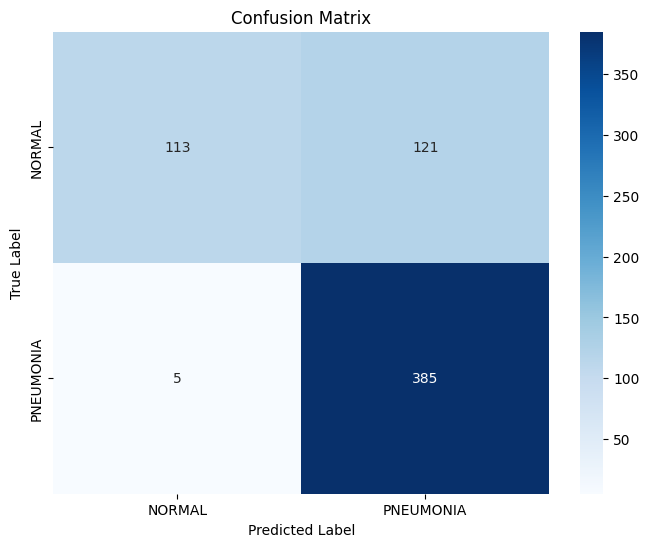

In [20]:
plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=train_dataset_full.classes,
    yticklabels=train_dataset_full.classes
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")

plt.show()

In [21]:
from sklearn.metrics import classification_report

print(classification_report(
    y_true,
    y_pred,
    target_names=train_dataset_full.classes
))

              precision    recall  f1-score   support

      NORMAL       0.96      0.48      0.64       234
   PNEUMONIA       0.76      0.99      0.86       390

    accuracy                           0.80       624
   macro avg       0.86      0.74      0.75       624
weighted avg       0.83      0.80      0.78       624

